# TDE 1
**Previsão de Séries Temporais**  ·  Gabriel Floriano

## 1. Recontextualização
- **Domínio:** segurança pública — ocorrências criminais por estado no Brasil.
- **Problema:** entender a evolução temporal (tendência e sazonalidade) das ocorrências para apoiar planejamento de segurança.
- **Fonte / dataset:** *Crimes no Brasil por estado* — Kaggle: https://www.kaggle.com/datasets/vianags/crimes-no-brasil-por-estado

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.filters import hp_filter
from scipy import stats
import kagglehub

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 2. Preparação e classificação dos dados

In [20]:
df = pd.read_csv(r"Crimes_brasil_uf.csv")

In [38]:
# Estrutura do dataset
df["Data"] = pd.to_datetime(df["Data"])   # converte Data (texto) -> datetime
print("Colunas:", df.columns.tolist())
print("UFs:", df["Uf"].nunique(), "| Tipos de crime:", df["Tipo_crime"].nunique())
print("Período:", df["Data"].min().date(), "->", df["Data"].max().date())
df.head()

Colunas: ['Uf', 'Tipo_crime', 'Ocorrencias', 'Data', '_data']
UFs: 27 | Tipos de crime: 9
Período: 2015-01-01 -> 2022-09-01


,Uf,Tipo_crime,Ocorrencias,Data,_data
0,Acre,Estupro,31,2022-01-01,2022-01-01
1,Acre,Furto de veículo,50,2022-01-01,2022-01-01
2,Acre,Homicídio doloso,10,2022-01-01,2022-01-01
3,Acre,Lesão corporal seguida de morte,1,2022-01-01,2022-01-01
4,Acre,Roubo a instituição financeira,0,2022-01-01,2022-01-01


In [23]:
# Inspeção rápida para decidir os nomes de coluna abaixo
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22338 entries, 0 to 22337
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Uf           22338 non-null  object
 1   Tipo_crime   22338 non-null  object
 2   Ocorrencias  22338 non-null  int64 
 3   Data         22338 non-null  object
dtypes: int64(1), object(3)
memory usage: 698.2+ KB


In [24]:
# CONFIG de colunas — nomes reais do dataset
COL_DATA  = "Data"
COL_ANO   = None
COL_MES   = None
COL_UF    = "Uf"
COL_CRIME = "Tipo_crime"
COL_VALOR = "Ocorrencias"

UF_ESCOLHIDA    = "Rio Grande do Sul"   # estado a analisar
CRIME_ESCOLHIDO = None                  # None = soma todos os crimes; ex.: "Homicídio doloso"

In [25]:
# Constrói a data mensal (usa COL_DATA se existir; senão monta a partir de ano/mes)
if COL_DATA in df.columns:
    df["_data"] = pd.to_datetime(df[COL_DATA])
else:
    df["_data"] = pd.to_datetime(dict(year=df[COL_ANO], month=df[COL_MES], day=1))

# Filtros: estado e (opcionalmente) tipo de crime
base = df[df[COL_UF] == UF_ESCOLHIDA].copy()
if COL_CRIME and CRIME_ESCOLHIDO:
    base = base[base[COL_CRIME] == CRIME_ESCOLHIDO]

# Agrega para série mensal (soma de ocorrências por mês)
serie = base.groupby("_data")[COL_VALOR].sum().sort_index()
serie = serie.asfreq("MS")   # frequência mensal explícita -> revela lacunas como NaN
serie.head()

_data
2015-01-01    4112
2015-02-01    3749
2015-03-01    4164
2015-04-01    3821
2015-05-01    3925
Freq: MS, Name: Ocorrencias, dtype: int64

In [26]:
# Consistência temporal: lacunas e duplicidades
print("Período:", serie.index.min(), "→", serie.index.max())
print("Nº de observações:", len(serie))
print("Meses faltantes (NaN):", int(serie.isna().sum()))
print("Datas duplicadas:", int(serie.index.duplicated().sum()))

# Tratamento de lacunas: interpolação temporal (se houver poucos buracos)
serie = serie.interpolate("time")

Período: 2015-01-01 00:00:00 → 2022-09-01 00:00:00
Nº de observações: 93
Meses faltantes (NaN): 0
Datas duplicadas: 0


**Classificação da série:** quantitativa, univariada, de frequência **mensal** e (após o `asfreq`)
**regularmente espaçada**. Contagem de ocorrências ≥ 0.

## 3. Gráficos

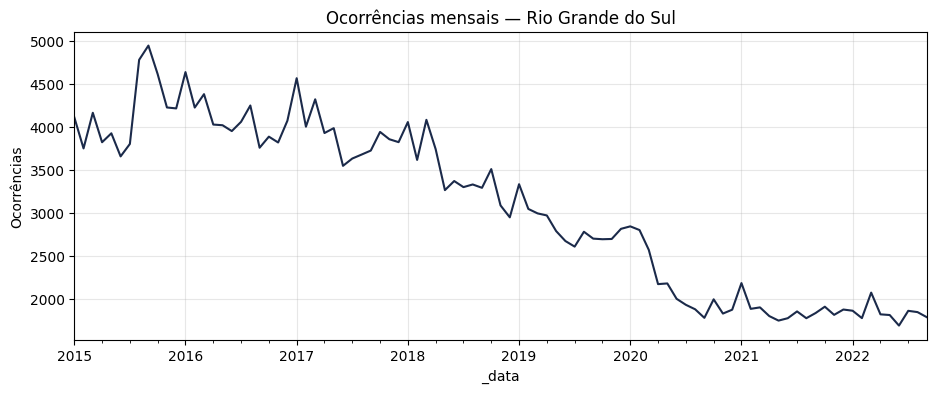

In [27]:
# a) Timeplot
serie.plot(title=f"Ocorrências mensais — {UF_ESCOLHIDA}", color="#1B2A4A")
plt.ylabel("Ocorrências"); plt.show()

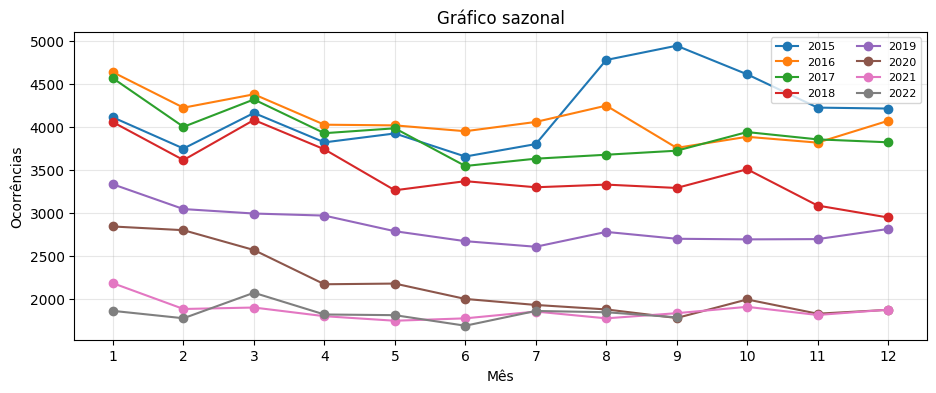

In [28]:
# b) Seasonal plot — uma linha por ano, meses no eixo X
aux = serie.to_frame("valor")
aux["ano"] = aux.index.year
aux["mes"] = aux.index.month

fig, ax = plt.subplots()
for ano, g in aux.groupby("ano"):
    ax.plot(g["mes"], g["valor"], marker="o", label=str(ano))
ax.set_xticks(range(1, 13)); ax.set_xlabel("Mês"); ax.set_ylabel("Ocorrências")
ax.set_title("Gráfico sazonal"); ax.legend(ncol=2, fontsize=8); plt.show()

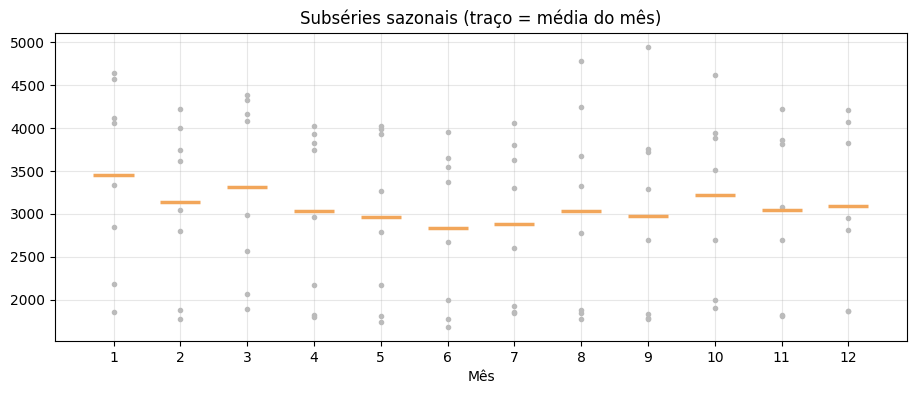

In [29]:
# c) Subséries sazonais — média de cada mês ao longo dos anos
media_mes = aux.groupby("mes")["valor"].mean()
fig, ax = plt.subplots()
for mes, g in aux.groupby("mes"):
    ax.plot([mes]*len(g), g["valor"], "o", color="#BBB", markersize=3)
    ax.hlines(media_mes[mes], mes-0.3, mes+0.3, color="#F2A65A", linewidth=2.5)
ax.set_xticks(range(1, 13)); ax.set_xlabel("Mês"); ax.set_title("Subséries sazonais (traço = média do mês)")
plt.show()

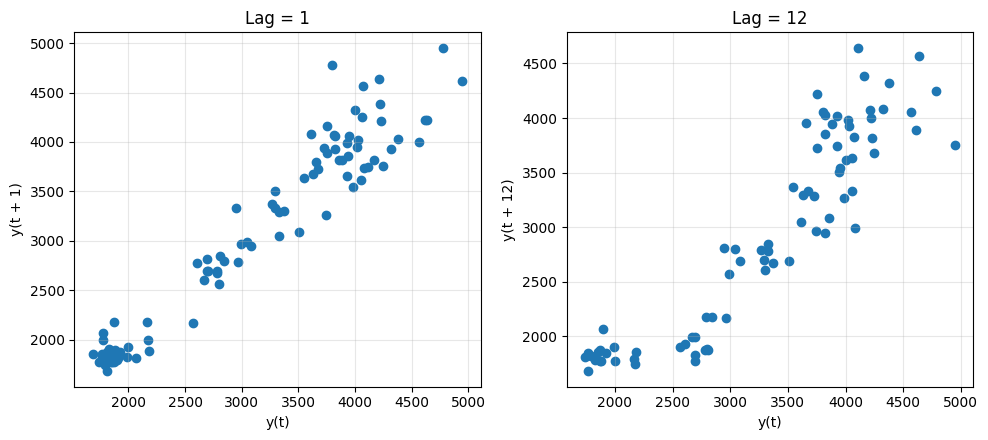

In [30]:
# d) Lag plot com 2 lags diferentes
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, lag in zip(axes, [1, 12]):
    pd.plotting.lag_plot(serie, lag=lag, ax=ax)
    ax.set_title(f"Lag = {lag}")
plt.tight_layout(); plt.show()

## 4. Transformação (log / Box-Cox)

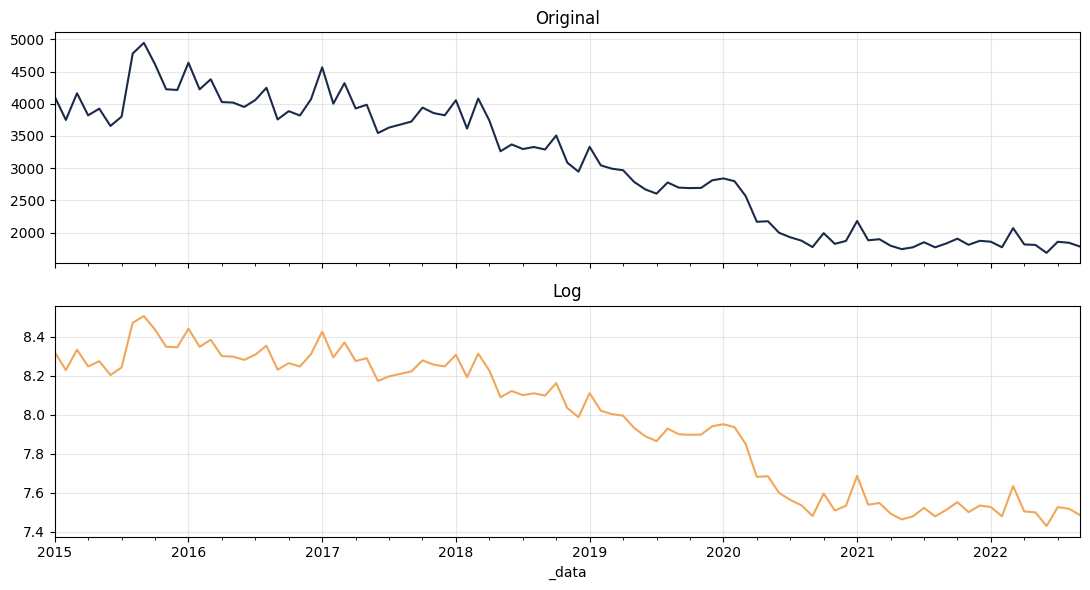

Lambda Box-Cox: 0.754


In [31]:
# Compara série original vs log (estabiliza variância se ela cresce com o nível)
serie_log = np.log(serie.replace(0, np.nan)).interpolate("time")

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
serie.plot(ax=axes[0], title="Original", color="#1B2A4A")
serie_log.plot(ax=axes[1], title="Log", color="#F2A65A")
plt.tight_layout(); plt.show()

# Box-Cox (opcional) — retorna também o lambda ótimo
bc, lam = stats.boxcox(serie[serie > 0])
print("Lambda Box-Cox:", round(lam, 3))

## 5. Decomposição

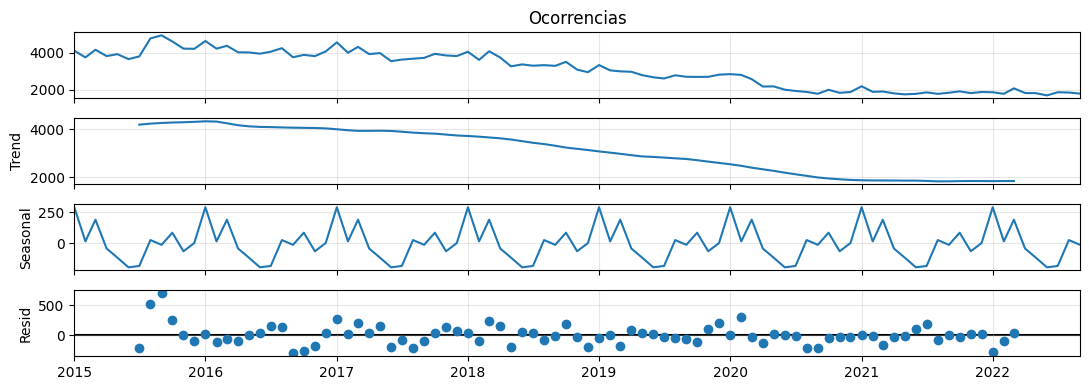

In [32]:
# Escolha aditivo x multiplicativo: multiplicativo se a amplitude sazonal cresce com o nível.
MODELO = "additive"   # ou "multiplicative"
dec = seasonal_decompose(serie, model=MODELO, period=12)
dec.plot(); plt.tight_layout(); plt.show()

**Interpretação:** comentar o que **tendência**, **sazonalidade** e **resíduo** revelam sobre as ocorrências.

## 6. Diferenciação

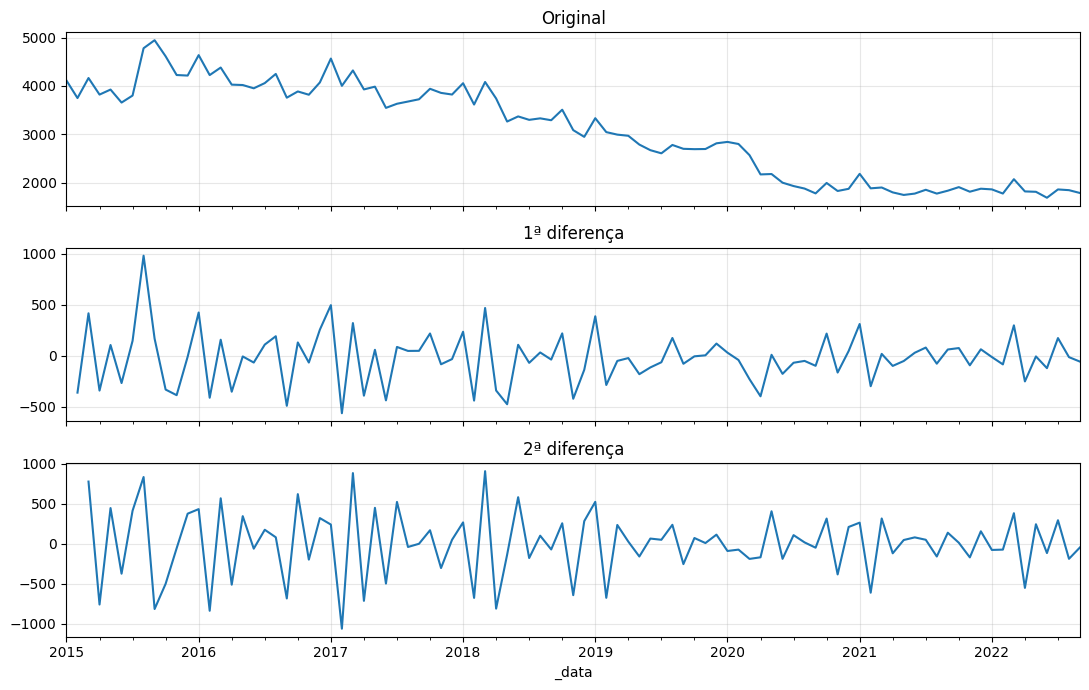

In [33]:
d1 = serie.diff()
d2 = serie.diff().diff()

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, dado, nome in zip(axes, [serie, d1, d2], ["Original", "1ª diferença", "2ª diferença"]):
    dado.plot(ax=ax, title=nome)
plt.tight_layout(); plt.show()

## 7. Suavização (mediana móvel vs média móvel)

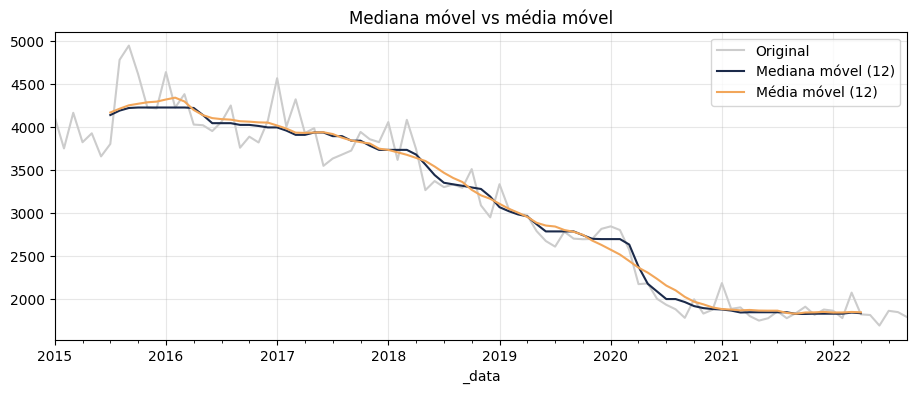

In [34]:
JANELA = 12
med_movel = serie.rolling(JANELA, center=True).median()
media_movel = serie.rolling(JANELA, center=True).mean()

serie.plot(label="Original", color="#CCC")
med_movel.plot(label=f"Mediana móvel ({JANELA})", color="#1B2A4A")
media_movel.plot(label=f"Média móvel ({JANELA})", color="#F2A65A")
plt.legend(); plt.title("Mediana móvel vs média móvel"); plt.show()

**Comparação:** a mediana móvel é robusta a *outliers*; a média móvel é mais suave mas sensível a picos.

## 8. Filtros

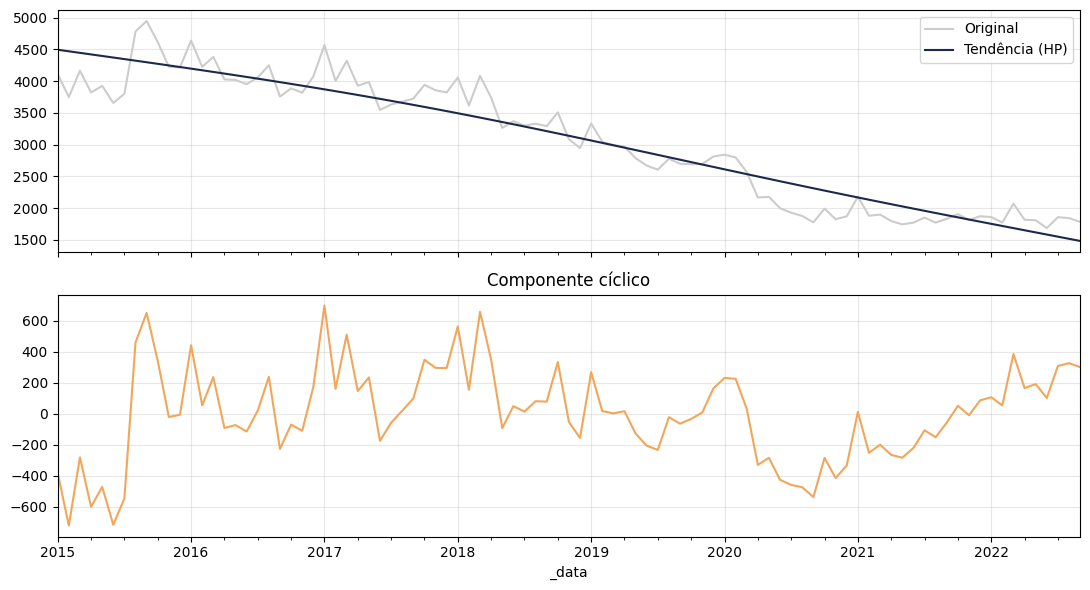

In [35]:
# Filtro Hodrick-Prescott: separa tendência suave + componente cíclico
ciclo, tendencia = hp_filter.hpfilter(serie, lamb=129600)  # lamb mensal

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
serie.plot(ax=axes[0], label="Original", color="#CCC")
tendencia.plot(ax=axes[0], label="Tendência (HP)", color="#1B2A4A"); axes[0].legend()
ciclo.plot(ax=axes[1], title="Componente cíclico", color="#F2A65A")
plt.tight_layout(); plt.show()

**Leitura:** a tendência HP mostra o movimento de longo prazo; o ciclo destaca desvios de curto prazo.

## 9. Síntese comparativa
Avaliar criticamente **quais técnicas ajudaram** a entender a série (decomposição, sazonalidade, filtro)
e **quais não agregaram** para este domínio, justificando cada conclusão.